
# Temporal Reachability Collapse (TRC)

## A Minimal Dynamical Model of Loss of Recoverability from Timing Mismatch

**Jaime Ojeda¹, ChatGPT (OpenAI)²**  
¹ Independent researcher  
² AI-assisted modeling and analysis

This notebook presents the minimal validated version of the TRC model used to test whether recovery depends not only on total input magnitude, but also on the temporal distribution of that input.

It shows only the core results:

1. matched-AUC inputs with different timing,  
2. deterministic timing-dependent recovery,  
3. stochastic recovery probability in the (AUC, duration) plane.

The goal is not to represent a specific biological mechanism, but to test whether loss of recoverability may emerge from timing mismatch while the recovered state remains part of the modeled state space.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11


## Model definition

In [2]:

def make_input(t, t_start=10.0, t_end=55.0, amplitude=1.0):
    u = np.zeros_like(t)
    u[(t >= t_start) & (t <= t_end)] = amplitude
    return u

def make_rect_input(t, t_start, duration, auc):
    u = np.zeros_like(t)
    amplitude = auc / duration
    t_end = t_start + duration
    u[(t >= t_start) & (t <= t_end)] = amplitude
    return u

def simulate_module_delay(t, u, tau, r, s, b, xc, K):
    dt = t[1] - t[0]
    x = np.zeros_like(t)

    delay_steps = max(1, int(round(tau / dt)))

    for i in range(1, len(t)):
        j = max(0, i - delay_steps)
        x_tau = x[j]

        nonlinear = b * x_tau * (x_tau - xc) * (1 - x_tau / K)
        dx = -r * x[i-1] + s * u[i-1] + nonlinear
        x[i] = x[i-1] + dt * dx

        if x[i] < 0:
            x[i] = 0.0
        if x[i] > 3.0:
            x[i] = 3.0

    return x

def simulate_with_noise(t, u, tau, r, s, b, xc, K, sigma=0.005):
    dt = t[1] - t[0]
    x = np.zeros_like(t)

    delay_steps = max(1, int(round(tau / dt)))

    for i in range(1, len(t)):
        j = max(0, i - delay_steps)
        x_tau = x[j]

        nonlinear = b * x_tau * (x_tau - xc) * (1 - x_tau / K)
        dx = -r * x[i-1] + s * u[i-1] + nonlinear

        noise = sigma * np.sqrt(dt) * np.random.randn()
        x[i] = x[i-1] + dt * dx + noise

        if x[i] < 0:
            x[i] = 0.0
        if x[i] > 3.0:
            x[i] = 3.0

    return x


## Parameters

In [3]:

t = np.linspace(0, 180, 4000)
dt = t[1] - t[0]

r_fixed = 0.42
b_fixed = 1.40
xc_fixed = 0.30
K_fixed = 2.0

tau_test = 6.5
s_test = 0.16

auc_target = 60.0
t_start = 10.0

sigma_noise = 0.005
recovery_threshold = 0.1
n_runs = 30

durations_noise = np.linspace(20, 90, 40)
auc_values = [30.0, 40.0, 50.0, 60.0, 70.0, 80.0]


## Figure 1. Matched-AUC inputs with different timing

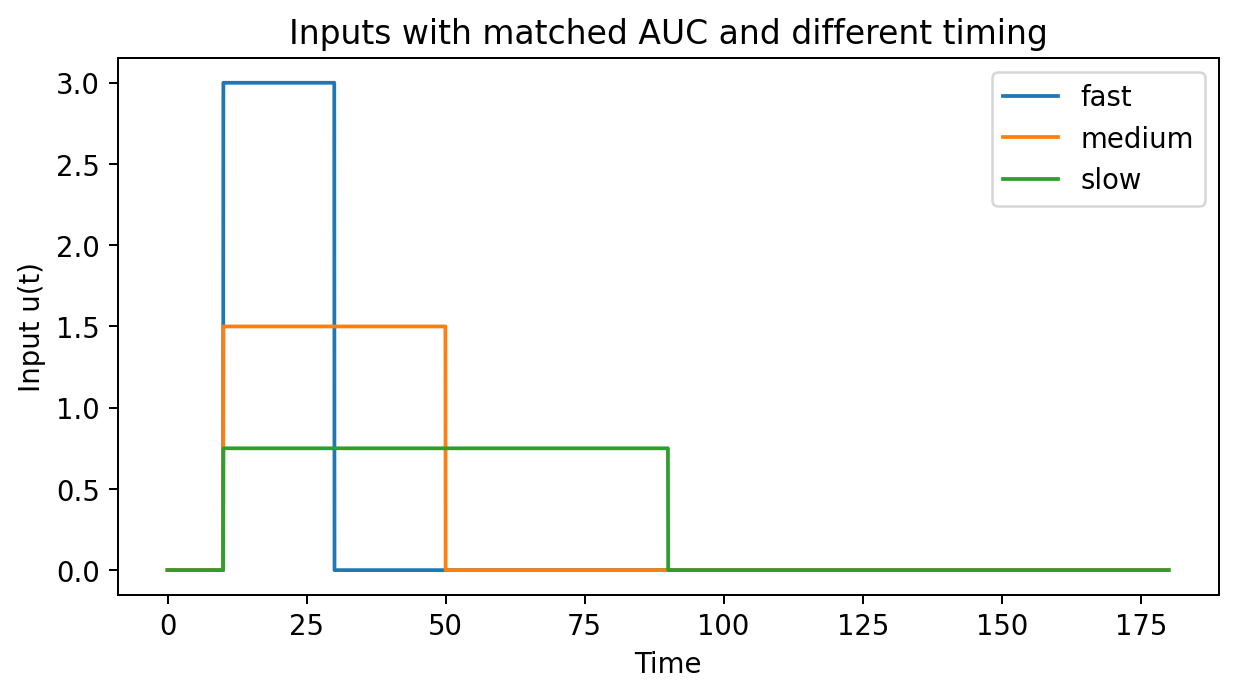

In [4]:

input_configs = [
    {"label": "fast",   "duration": 20.0},
    {"label": "medium", "duration": 40.0},
    {"label": "slow",   "duration": 80.0},
]

inputs_auc = {}

for cfg in input_configs:
    label = cfg["label"]
    duration = cfg["duration"]
    inputs_auc[label] = make_rect_input(t, t_start=t_start, duration=duration, auc=auc_target)

plt.figure(figsize=(7,4), dpi=180)

for label, u_test in inputs_auc.items():
    plt.plot(t, u_test, label=label)

plt.xlabel("Time")
plt.ylabel("Input u(t)")
plt.title("Inputs with matched AUC and different timing")
plt.legend()
plt.tight_layout()
plt.savefig("fig1_inputs_matched_auc.png", bbox_inches="tight")
plt.show()


## Figure 2. Deterministic recovery depends on timing under matched AUC

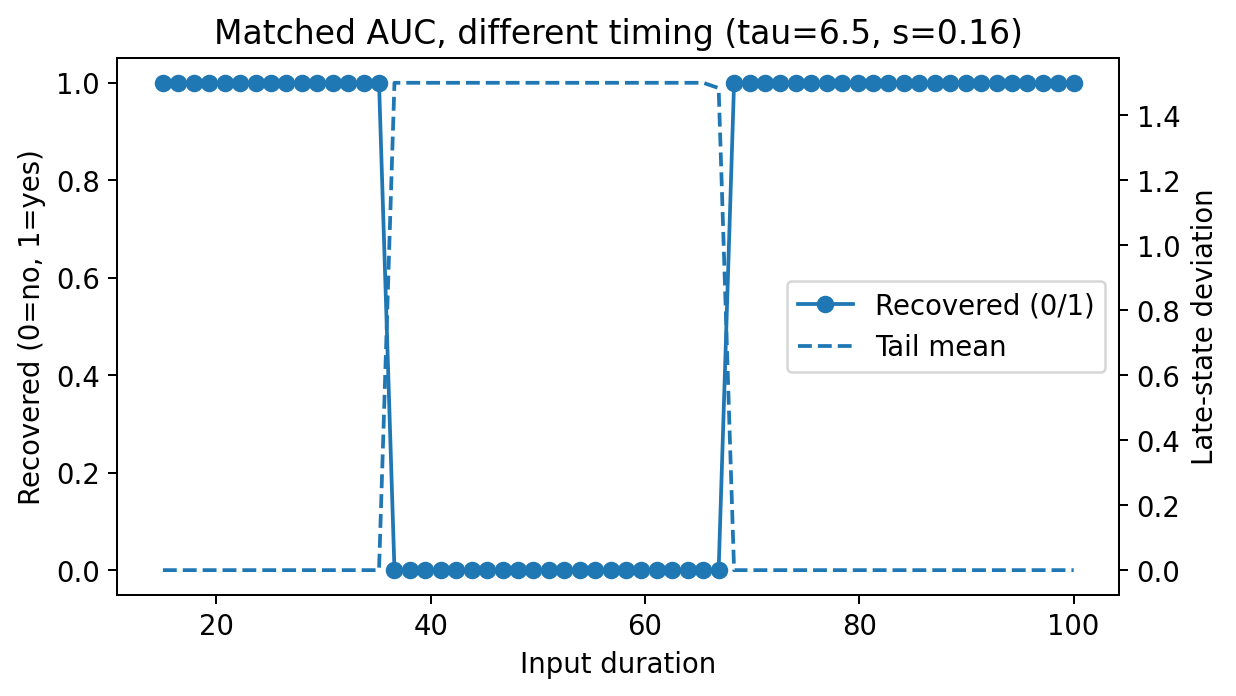

,duration,recovered,tail_mean,x_max,x_final
0,15.000000,1,0.0,2.915120,0.0
1,16.440678,1,0.0,2.784247,0.0
2,17.881356,1,0.0,2.651970,0.0
3,19.322034,1,0.0,2.534835,0.0
4,20.762712,1,0.0,2.438816,0.0


In [5]:

durations = np.linspace(15, 100, 60)

duration_rows = []

for dur in durations:
    u_test = make_rect_input(t, t_start=t_start, duration=dur, auc=auc_target)

    x = simulate_module_delay(
        t, u_test, tau=tau_test,
        r=r_fixed, s=s_test, b=b_fixed, xc=xc_fixed, K=K_fixed
    )

    tail = x[int(0.8 * len(x)):]
    recovered = int(x[-1] < recovery_threshold)

    duration_rows.append({
        "duration": dur,
        "recovered": recovered,
        "tail_mean": np.mean(tail),
        "x_max": np.max(x),
        "x_final": x[-1]
    })

duration_df = pd.DataFrame(duration_rows)

fig, ax1 = plt.subplots(figsize=(7,4), dpi=180)

ax1.plot(duration_df["duration"], duration_df["recovered"], marker="o", label="Recovered (0/1)")
ax1.set_xlabel("Input duration")
ax1.set_ylabel("Recovered (0=no, 1=yes)")
ax1.set_title(f"Matched AUC, different timing (tau={tau_test}, s={s_test})")

ax2 = ax1.twinx()
ax2.plot(duration_df["duration"], duration_df["tail_mean"], linestyle="--", label="Tail mean")
ax2.set_ylabel("Late-state deviation")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.savefig("fig2_matched_auc_timing_dependence.png", bbox_inches="tight")
plt.show()

duration_df.to_csv("fig2_matched_auc_timing_dependence.csv", index=False)
duration_df.head()


## Figure 3. Stochastic recovery probability in the (AUC, duration) plane

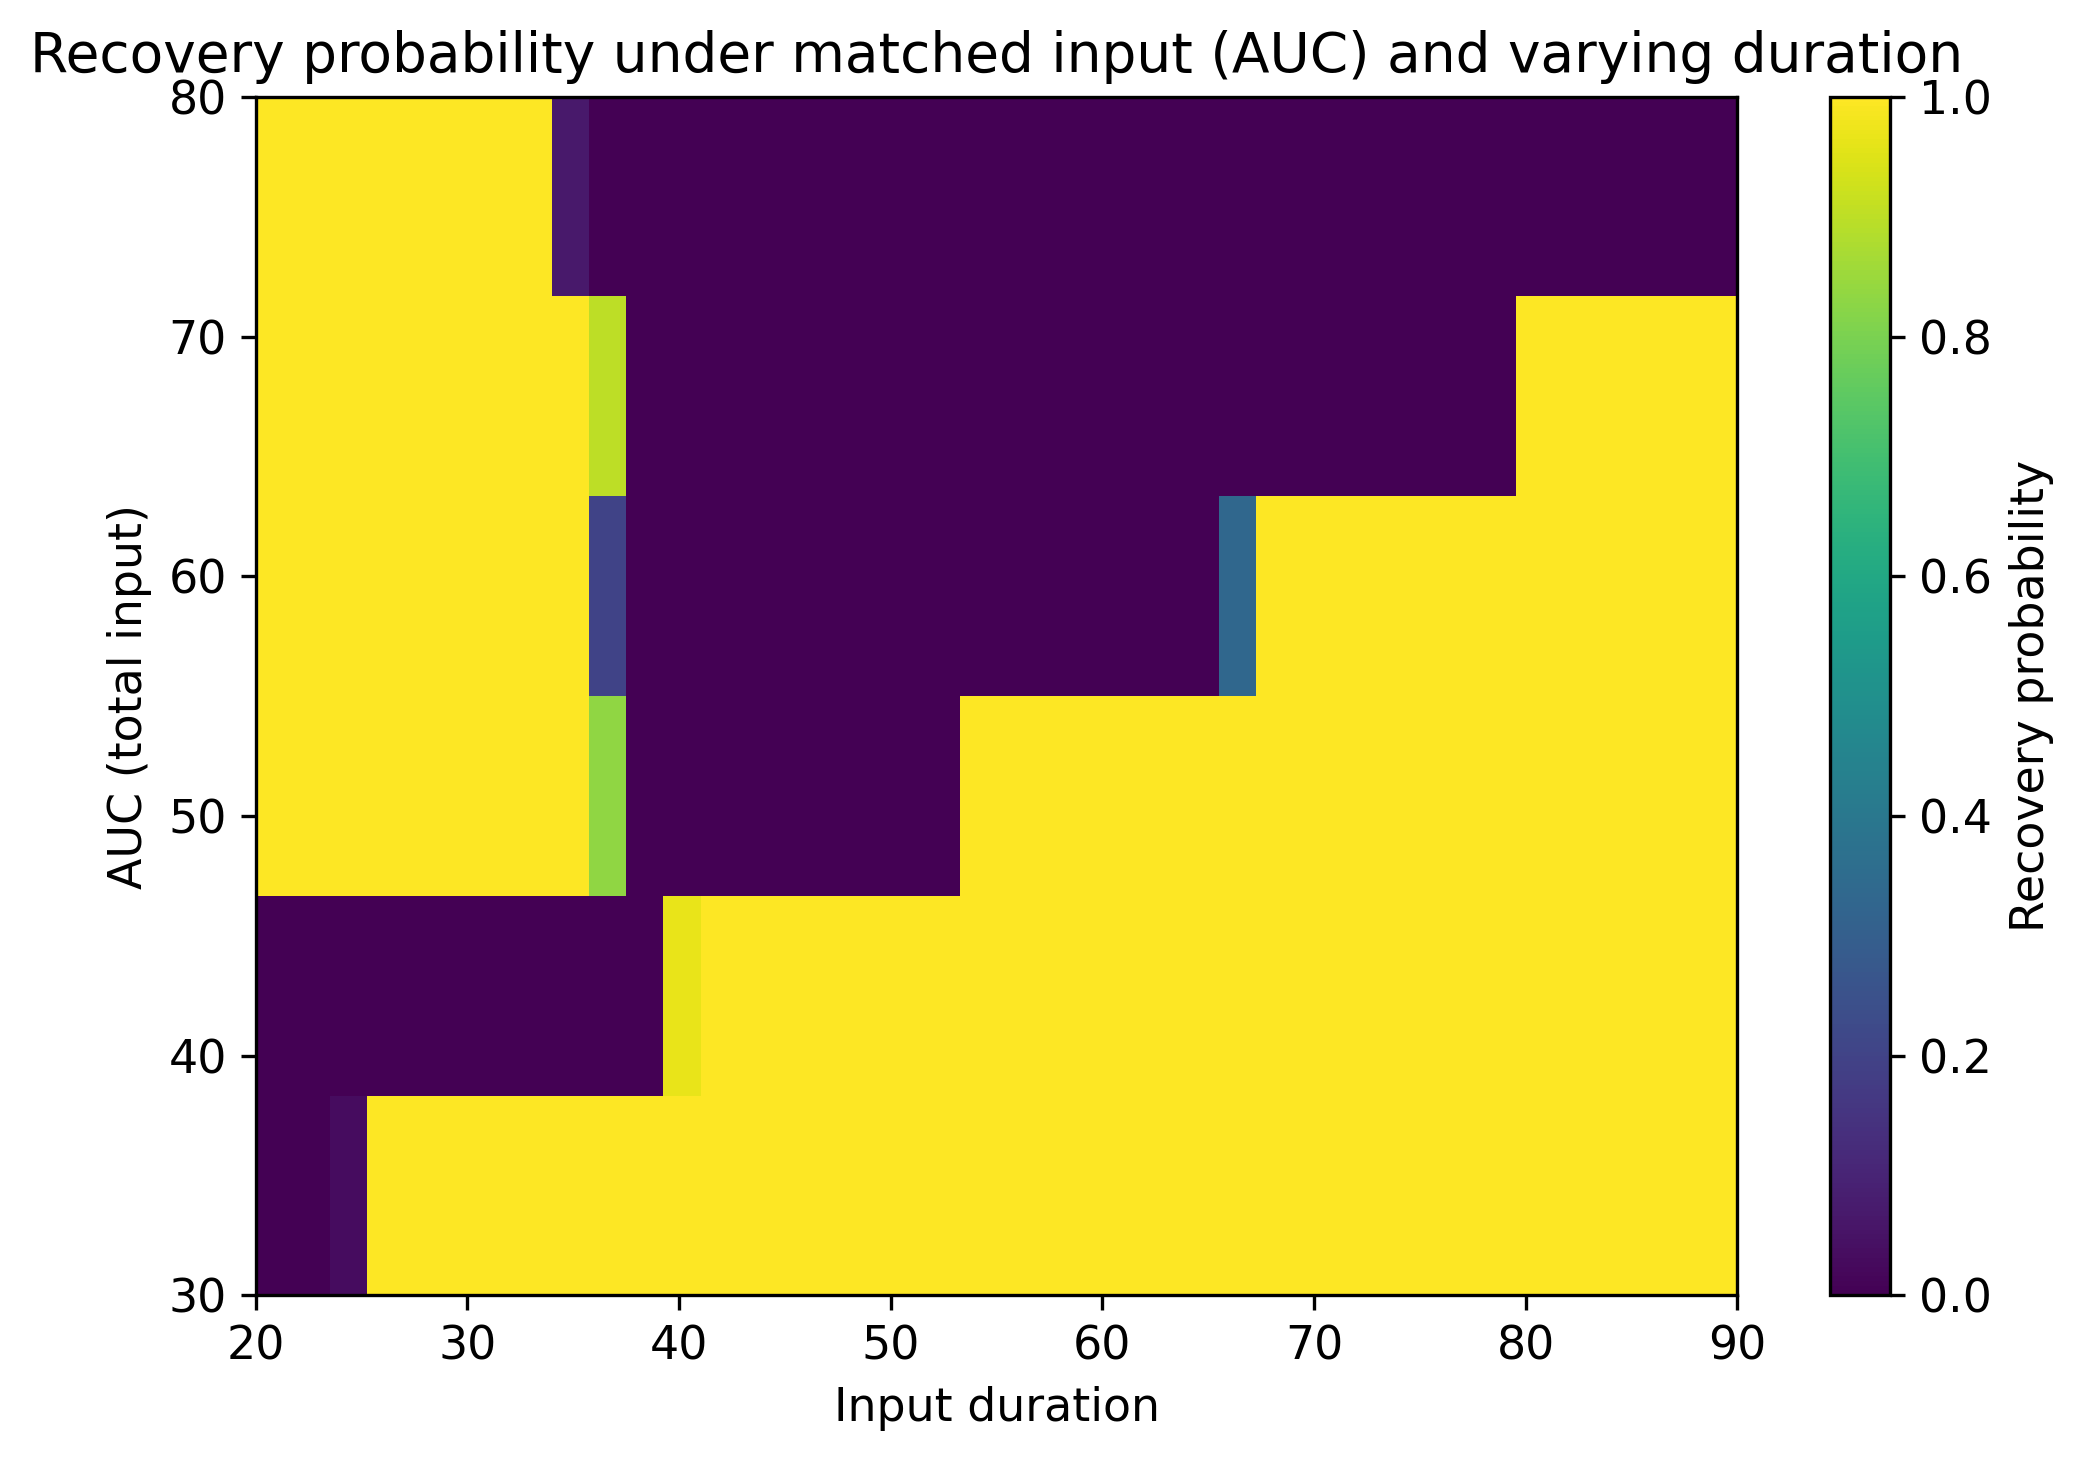

,20.00,21.79,23.59,25.38,27.18,28.97,30.77,32.56,34.36,36.15,...,73.85,75.64,77.44,79.23,81.03,82.82,84.62,86.41,88.21,90.00
30.0,0.0,0.0,0.033333,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
40.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.833333,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
60.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.200000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
70.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.900000,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
80.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.066667,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:

all_results = []

for auc_test in auc_values:
    results_noise = []

    for dur in durations_noise:
        u_test = make_rect_input(t, t_start=t_start, duration=dur, auc=auc_test)

        recoveries = []

        for _ in range(n_runs):
            x = simulate_with_noise(
                t, u_test,
                tau=tau_test,
                r=r_fixed, s=s_test,
                b=b_fixed, xc=xc_fixed, K=K_fixed,
                sigma=sigma_noise
            )
            recoveries.append(int(x[-1] < recovery_threshold))

        results_noise.append(np.mean(recoveries))

    all_results.append(results_noise)

all_results = np.array(all_results)

plt.figure(figsize=(7,5), dpi=300)

im = plt.imshow(
    all_results,
    aspect="auto",
    origin="lower",
    extent=[durations_noise.min(), durations_noise.max(), auc_values[0], auc_values[-1]],
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label("Recovery probability")

plt.xlabel("Input duration")
plt.ylabel("AUC (total input)")
plt.title("Recovery probability under matched input (AUC) and varying duration")

plt.tight_layout()
plt.savefig("fig3_recovery_probability_phase_diagram.png", dpi=300, bbox_inches="tight")
plt.savefig("fig3_recovery_probability_phase_diagram.pdf", bbox_inches="tight")
plt.show()

noise_phase_df = pd.DataFrame(
    all_results,
    index=auc_values,
    columns=np.round(durations_noise, 2)
)
noise_phase_df.to_csv("fig3_recovery_probability_phase_diagram.csv")
noise_phase_df



## Minimal interpretation

This validated minimal notebook shows that recovery may depend not only on total input (AUC), but also on how that same total input is distributed in time.

The deterministic timing sweep shows a non-monotonic dependence of recovery on duration at fixed AUC.  
The stochastic phase diagram shows a probabilistic boundary in the (AUC, duration) plane, separating high-recovery and low-recovery regimes.

This is consistent with a loss of dynamic accessibility rather than removal of the recovered state.
